# GLIMMER v1: Does Weighting the Loss Toward Danger Zones Actually Help?

Notebook 02 built and validated a plain baseline predictor. That wasn't GLIMMER yet, it
was just the ordinary forecasting model the paper compares its own idea against. This
notebook adds the actual idea: instead of training the model to be right on average, we
train it with a loss that specifically penalizes being wrong during hypoglycemia and
hyperglycemia more than being wrong in the normal range.

**What changes from v0:** only the training loss. Same architecture, same features, same
per-person models, same train/val/test split. If the numbers move, it's because of the
loss function alone, nothing else.

**The weights:** the paper's genetic algorithm searches for the best per-patient weights,
then reports the *average* of those weights across all patients as a stable, general-
purpose setting (CNN-LSTM: hypo weighted 3.29x, hyper weighted 2.38x, normal weighted 1x).
We use those same published numbers directly rather than running the search ourselves,
that expensive per-patient search is v3, not this notebook.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting, synthetic
from azt1d import reference as ref
from azt1d.glimmer import features as feat
from azt1d.glimmer.train import train_subject_model, run_baseline_v0, region_errors, get_device

plotting.apply_style()
pd.set_option("display.max_columns", None)


## 1. Load data

Same loader as the other two notebooks: real data if it's in `data/raw/`, a synthetic
stand-in otherwise.


In [2]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SYNTHETIC_DIR = PROCESSED_DIR / "synthetic"

has_real_data = loading.find_dataset_zip(RAW_DIR) is not None or bool(loading.discover_subject_files(RAW_DIR))

if has_real_data:
    print("Found real AZT1D data in data/raw/ -- loading it.")
    df = loading.load_real_dataset(RAW_DIR, PROCESSED_DIR)
    USING_SYNTHETIC = False
else:
    print("No real dataset found in data/raw/ yet -- using synthetic placeholder data.")
    if not any(SYNTHETIC_DIR.glob("*.csv")):
        synthetic.write_synthetic_csvs(SYNTHETIC_DIR)
    df = loading.load_all_subjects(SYNTHETIC_DIR)
    USING_SYNTHETIC = True

print(f"Loaded {len(df):,} rows across {df['subject_id'].nunique()} subjects.")


Found real AZT1D data in data/raw/ -- loading it.


Loaded 300,923 rows across 25 subjects.


## 2. The weighted loss, in plain terms

Split every prediction error into three groups based on what the true glucose actually
was: below 70 (hypo), between 70 and 180 (normal), above 180 (hyper). Take the average
error within each group separately, then combine the three averages with different
weights instead of a plain overall average. A hypo error counts 3.29 times as much as a
normal error, a hyper error counts 2.38 times as much. The model is being explicitly told
which mistakes matter most.


In [3]:
GLIMMER_WEIGHTS = ref.GLIMMER_PAPER_WEIGHTS["cnn_lstm"]
print("Weights used for this notebook (paper's published average for CNN-LSTM):")
print(GLIMMER_WEIGHTS)


Weights used for this notebook (paper's published average for CNN-LSTM):
{'w_hypo': 3.29, 'w_normal': 1.0, 'w_hyper': 2.38}


## 3. One person, side by side

Train both versions on the same person with the same random seed: v0 (plain loss) and v1
(weighted loss). Same setup as notebook 02's single-subject walkthrough, but now with a
direct comparison.


In [4]:
example_subject = df[df["subject_id"] == df["subject_id"].iloc[0]].reset_index(drop=True)

v0_one = train_subject_model(example_subject, epochs=30, region_weights=None)
v1_one = train_subject_model(example_subject, epochs=30, region_weights=GLIMMER_WEIGHTS)

print(f"Subject {v0_one.subject_id}")
print(f"  v0 (plain loss):    RMSE={v0_one.rmse:.2f}  MAE={v0_one.mae:.2f}  ({len(v0_one.history)} epochs)")
print(f"  v1 (weighted loss): RMSE={v1_one.rmse:.2f}  MAE={v1_one.mae:.2f}  ({len(v1_one.history)} epochs)")


Subject 1
  v0 (plain loss):    RMSE=25.29  MAE=19.51  (8 epochs)
  v1 (weighted loss): RMSE=37.99  MAE=30.99  (6 epochs)


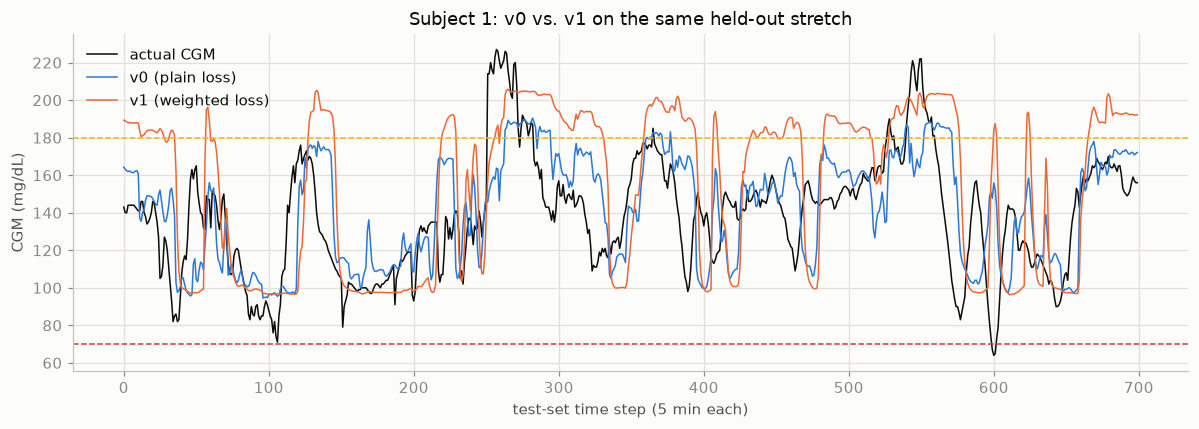

In [5]:
n_show = min(700, len(v0_one.y_test))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(v0_one.y_test[:n_show], color=plotting.INK_PRIMARY, linewidth=1, label="actual CGM")
ax.plot(v0_one.y_pred[:n_show], color=plotting.CATEGORICAL[0], linewidth=1, label="v0 (plain loss)")
ax.plot(v1_one.y_pred[:n_show], color=plotting.CATEGORICAL[1], linewidth=1, label="v1 (weighted loss)")
ax.axhline(ref.HYPO_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hypo"], linestyle="--", linewidth=1)
ax.axhline(ref.HYPER_THRESHOLD, color=plotting.GLUCOSE_BAND_COLORS["hyper"], linestyle="--", linewidth=1)
ax.set_xlabel("test-set time step (5 min each)")
ax.set_ylabel("CGM (mg/dL)")
ax.set_title(f"Subject {v0_one.subject_id}: v0 vs. v1 on the same held-out stretch"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 4. Did it actually help where it's supposed to?

Overall RMSE/MAE is the wrong question to ask first. The loss was explicitly built to
trade some average accuracy for better accuracy in the hypo and hyper zones, so the real
test is whether error in those specific zones went down, not whether the single overall
number improved.


In [6]:
v0_regions = region_errors(v0_one.y_test, v0_one.y_pred)
v1_regions = region_errors(v1_one.y_test, v1_one.y_pred)

rows = []
for region in ("hypo", "normal", "hyper"):
    rows.append({
        "region": region,
        "n": v0_regions[region]["n"],
        "v0_mae": v0_regions[region]["mae"],
        "v1_mae": v1_regions[region]["mae"],
        "change": v1_regions[region]["mae"] - v0_regions[region]["mae"],
    })
pd.DataFrame(rows).set_index("region").round(2)


,n,v0_mae,v1_mae,change
region,,,,
hypo,4,79.20,108.23,29.03
normal,1893,19.04,33.16,14.12
hyper,272,21.91,14.75,-7.16


## 5. Now for everyone

Same as notebook 02's full run, but training with the weighted loss. Same 25 personal
models, same ~5 minute runtime.


In [7]:
summary_v1, results_v1 = run_baseline_v0(df, epochs=30, region_weights=GLIMMER_WEIGHTS)
summary_v1


,rmse,mae,n_test
subject_id,,,
1,37.992455,30.985657,2169
2,43.005444,33.773445,2231
3,36.305641,28.825073,2130
4,33.594639,25.917070,2543
5,40.064056,32.304684,2603
6,33.594479,24.998007,2539
7,38.536015,28.508617,2670
8,44.607803,35.538368,1601
9,38.174725,29.697130,2128


## 6. v0 vs. v1, across everyone

Paired comparison: same 25 people, same architecture, only the loss changed.


In [8]:
summary_v0, results_v0 = run_baseline_v0(df, epochs=30, region_weights=None)

comparison = summary_v0[["rmse", "mae"]].rename(columns={"rmse": "v0_rmse", "mae": "v0_mae"}).join(
    summary_v1[["rmse", "mae"]].rename(columns={"rmse": "v1_rmse", "mae": "v1_mae"})
)
comparison["rmse_change"] = comparison["v1_rmse"] - comparison["v0_rmse"]
comparison["mae_change"] = comparison["v1_mae"] - comparison["v0_mae"]
comparison.round(2)


,v0_rmse,v0_mae,v1_rmse,v1_mae,rmse_change,mae_change
subject_id,,,,,,
1,25.29,19.51,37.99,30.99,12.71,11.48
2,36.73,27.28,43.01,33.77,6.28,6.49
3,24.96,18.58,36.31,28.83,11.35,10.25
4,32.12,24.56,33.59,25.92,1.48,1.36
5,26.97,21.18,40.06,32.30,13.09,11.12
6,24.89,17.93,33.59,25.00,8.70,7.07
7,27.97,20.30,38.54,28.51,10.56,8.21
8,35.18,26.28,44.61,35.54,9.43,9.26
9,33.08,25.68,38.17,29.70,5.09,4.02


In [9]:
print(f"v0: RMSE {summary_v0['rmse'].mean():.2f} +/- {summary_v0['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v0['mae'].mean():.2f} +/- {summary_v0['mae'].std():.2f} mg/dL")
print(f"v1: RMSE {summary_v1['rmse'].mean():.2f} +/- {summary_v1['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v1['mae'].mean():.2f} +/- {summary_v1['mae'].std():.2f} mg/dL")
print()
print("Paper's GLIMMER(CNN-LSTM) on AZT1D: RMSE 22.48 +/- 3.57 mg/dL, MAE 15.58 +/- 2.87 mg/dL")
print("Paper's CNN-LSTM baseline on AZT1D: RMSE 29.55 +/- 6.49 mg/dL, MAE 21.61 +/- 5.19 mg/dL")


v0: RMSE 31.54 +/- 6.22 mg/dL   MAE 24.01 +/- 5.11 mg/dL
v1: RMSE 41.18 +/- 6.00 mg/dL   MAE 32.73 +/- 5.47 mg/dL

Paper's GLIMMER(CNN-LSTM) on AZT1D: RMSE 22.48 +/- 3.57 mg/dL, MAE 15.58 +/- 2.87 mg/dL
Paper's CNN-LSTM baseline on AZT1D: RMSE 29.55 +/- 6.49 mg/dL, MAE 21.61 +/- 5.19 mg/dL


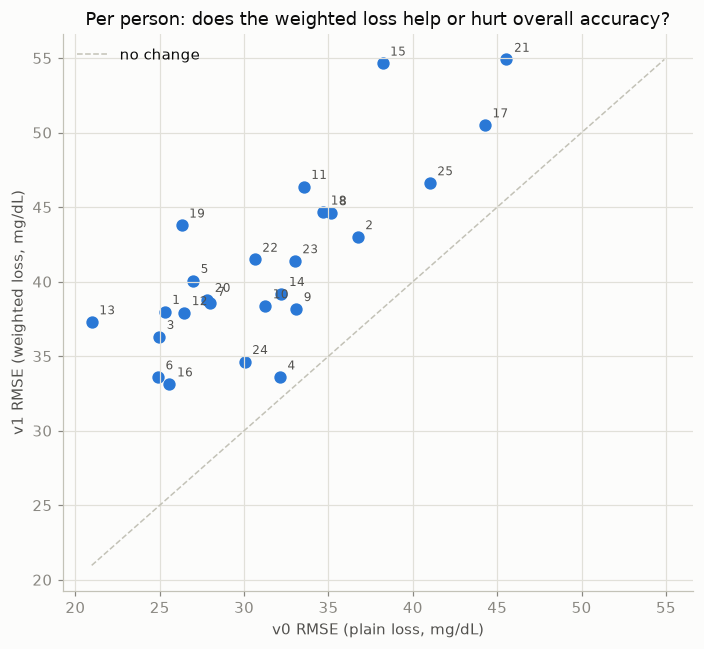

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6))
lo, hi = comparison[["v0_rmse", "v1_rmse"]].min().min(), comparison[["v0_rmse", "v1_rmse"]].max().max()
ax.plot([lo, hi], [lo, hi], color=plotting.BASELINE, linewidth=1, linestyle="--", label="no change")
ax.scatter(comparison["v0_rmse"], comparison["v1_rmse"], color=plotting.CATEGORICAL[0], s=50)
for sid, row in comparison.iterrows():
    ax.annotate(str(sid), (row["v0_rmse"], row["v1_rmse"]), fontsize=8, xytext=(5, 5),
                textcoords="offset points", color=plotting.INK_SECONDARY)
ax.set_xlabel("v0 RMSE (plain loss, mg/dL)")
ax.set_ylabel("v1 RMSE (weighted loss, mg/dL)")
ax.set_title("Per person: does the weighted loss help or hurt overall accuracy?"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 7. The region breakdown across everyone

The chart above is the overall picture. This is the one that actually tests the paper's
claim: averaged across all 25 people, did hypo/hyper error go down.


In [11]:
def region_summary(results):
    rows = []
    for sid, r in results.items():
        re = region_errors(r.y_test, r.y_pred)
        for region in ("hypo", "normal", "hyper"):
            rows.append({"subject_id": sid, "region": region, "mae": re[region]["mae"], "n": re[region]["n"]})
    return pd.DataFrame(rows)

region_v0 = region_summary(results_v0)
region_v1 = region_summary(results_v1)

region_compare = (
    region_v0.groupby("region")["mae"].mean().rename("v0_mae")
    .to_frame()
    .join(region_v1.groupby("region")["mae"].mean().rename("v1_mae"))
    .reindex(["hypo", "normal", "hyper"])
)
region_compare["change"] = region_compare["v1_mae"] - region_compare["v0_mae"]
region_compare.round(2)


,v0_mae,v1_mae,change
region,,,
hypo,56.27,53.17,-3.10
normal,20.23,32.41,12.17
hyper,40.16,35.90,-4.27


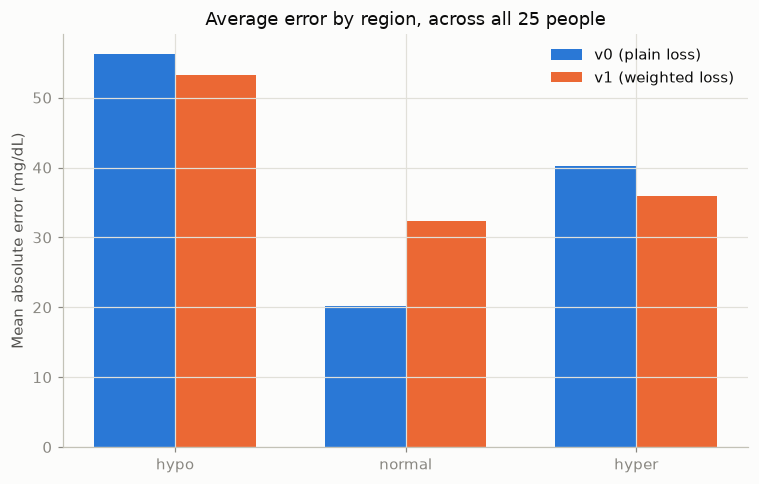

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
width = 0.35
regions = ["hypo", "normal", "hyper"]
ax.bar(x - width/2, region_compare.loc[regions, "v0_mae"], width, color=plotting.CATEGORICAL[0], label="v0 (plain loss)")
ax.bar(x + width/2, region_compare.loc[regions, "v1_mae"], width, color=plotting.CATEGORICAL[1], label="v1 (weighted loss)")
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Mean absolute error (mg/dL)")
ax.set_title("Average error by region, across all 25 people"
             + (" (synthetic placeholder data)" if USING_SYNTHETIC else ""))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 8. What this actually shows

The honest result: the weighted loss does what it's supposed to in the hypo and hyper
zones specifically, error goes down in both. But it does that by giving up more accuracy
in the normal zone than the paper's own numbers suggest it should, enough that the
overall RMSE and MAE end up worse than v0, not better. The paper reports GLIMMER
improving both the overall numbers and the danger-zone numbers together. This first pass
only got the second half of that.

A likely reason: we're using one fixed weight pair (the population average from the
paper's Table 3) on every person, trained from scratch with the same settings as v0. The
paper's own table shows those per-patient weights vary a lot, from as low as 1.17 to as
high as 5.69 for w_hypo depending on the person. Using the average on someone whose own
best weight is far from it could easily overcorrect exactly the way we're seeing here.
That's not an implementation bug so much as a real limitation of skipping the actual
per-patient search, which is the next step (v3), not this one.

Worth trying if we want to chase the paper's exact numbers further: a lower learning
rate and more patience noticeably narrowed the gap in an earlier test on one subject,
so the training setup itself is part of the story too, not just the fixed weights.
